# Modèle de **probabilité de bottom** & accumulation TQQQ

Idée : pendant un krach, produire chaque jour une **probabilité d'être proche du point bas** (0 = sûrement pas,
0,7 = ~70 % de chances d'être au bottom, 0,99 = quasi-certain). On utilise ce signal pour **accumuler du TQQQ
en plusieurs fois**, d'autant plus fort que la conviction est élevée.

## ⚠️ Interdiction absolue du look-ahead
Un « bottom » ne se connaît qu'**après coup** → le *label* d'entraînement est forcément forward-looking.
Pour que ce ne soit **pas** de la triche, on impose :

1. **Features 100 % causales** : à la date `t`, chaque variable n'utilise que des données **≤ t**
   (SMA, VIX, écart-type glissant, et leurs **percentiles vs l'historique passé** via des fenêtres *expanding*).
2. **Séparation chronologique train / test** : le modèle est entraîné uniquement sur la **1ʳᵉ partie**
   de l'histoire ; toutes les probabilités jugées et le backtest se font sur la **2ᵉ partie (hors-échantillon)**.
3. **Standardisation apprise sur le train seulement** (Pipeline sklearn).
4. **Signal décalé d'1 jour** avant d'agir.

Le label forward ne sert **qu'à apprendre** sur le passé ; il n'entre jamais dans les features ni dans le test.
Features & modèle sur l'indice sous-jacent **`^NDX` + `^VIX`** ; on trade **TQQQ**.

## 1. Imports & données (cache local)

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
plt.rcParams["figure.figsize"] = (13, 5); AF = 252

def load(name):
    return pd.read_csv(f"data_cache/{name}.csv", parse_dates=["date"]).set_index("date")["close"].dropna()

ndx, vix, tqqq = load("ndx"), load("vix"), load("tqqq")
df = pd.DataFrame({"ndx": ndx, "vix": vix.reindex(ndx.index, method="ffill")}).dropna()
print(f"^NDX+VIX : {df.index.min().date()} -> {df.index.max().date()}  ({len(df)} j)")
print(f"TQQQ     : {tqqq.index.min().date()} -> {tqqq.index.max().date()}")

^NDX+VIX : 1990-01-02 -> 2026-07-02  (9192 j)
TQQQ     : 2010-02-11 -> 2026-07-02


## 2. Features **causales** (aucune donnée future)

Toutes calculées à partir du prix `^NDX` et du `^VIX` connus à la clôture de `t`. On « compare à l'historique »
via des **percentiles expanding** (rang de la valeur du jour parmi tout le passé, recalculé jour après jour).

In [2]:
def expanding_pct(s, min_periods=252):
    """Rang percentile de s[t] parmi s[0..t] (causal). NaN tant que < min_periods."""
    return s.expanding(min_periods=min_periods).apply(
        lambda x: (x[-1] >= x).mean(), raw=True)

p = df["ndx"]; v = df["vix"]
ret = p.pct_change()
feat = pd.DataFrame(index=df.index)

run_peak = p.cummax()                              # sommet glissant CAUSAL
feat["drawdown"]   = p / run_peak - 1              # profondeur du drawdown courant (<=0)
feat["days_peak"]  = (np.arange(len(p)) - pd.Series(np.arange(len(p)), index=p.index)
                        .where(p == run_peak).ffill().fillna(0).values)
feat["dist_sma50"] = p / p.rolling(50).mean()  - 1
feat["dist_sma200"]= p / p.rolling(200).mean() - 1
feat["ret_5"]      = p.pct_change(5)
feat["ret_20"]     = p.pct_change(20)
feat["rvol_20"]    = ret.rolling(20).std()
feat["rvol_pct"]   = expanding_pct(feat["rvol_20"])       # vol réalisée vs son histoire
feat["vix"]        = v
feat["vix_pct"]    = expanding_pct(v)                      # VIX vs son histoire
feat["vix_z"]      = (v - v.rolling(50).mean()) / v.rolling(50).std()
feat["vix_ratio"]  = v / v.rolling(50).mean()             # spike VIX vs sa MA
feat["vix_chg5"]   = v.diff(5)

FEATURES = ["drawdown","days_peak","dist_sma50","dist_sma200","ret_5","ret_20",
            "rvol_20","rvol_pct","vix","vix_pct","vix_z","vix_ratio","vix_chg5"]
feat = feat.replace([np.inf,-np.inf], np.nan)
print("features:", FEATURES)
feat[FEATURES].describe().T[["mean","std","min","max"]].round(3)

features: ['drawdown', 'days_peak', 'dist_sma50', 'dist_sma200', 'ret_5', 'ret_20', 'rvol_20', 'rvol_pct', 'vix', 'vix_pct', 'vix_z', 'vix_ratio', 'vix_chg5']


,mean,std,min,max
drawdown,-0.263,0.275,-0.829,0.000
days_peak,870.425,1201.171,0.000,3925.000
dist_sma50,0.014,0.060,-0.324,0.237
dist_sma200,0.059,0.128,-0.540,0.594
ret_5,0.003,0.034,-0.252,0.212
ret_20,0.013,0.066,-0.313,0.403
rvol_20,0.014,0.009,0.003,0.069
rvol_pct,0.467,0.312,0.000,0.996
vix,19.454,7.744,9.140,82.690
vix_pct,0.489,0.307,0.000,1.000


## 3. Label de bottom (**forward — sert uniquement à l'entraînement**)

On marque `t` comme *bottom* si, dans une **fenêtre future** de `FW` jours, le prix ne descend quasiment pas plus
bas (on est à ≤ `TOL` du minimum futur) **et** qu'on est bien dans un **drawdown significatif** (≥ `DD_MIN`).
Ce label utilise le futur : il **n'apparaît jamais dans les features** et ne sera lu **que sur la période train**.

In [3]:
FW, TOL, DD_MIN = 40, 0.04, 0.15
fwd_min = p[::-1].rolling(FW, min_periods=1).min()[::-1]     # min du prix sur [t, t+FW-1]
near_bottom = p <= fwd_min * (1 + TOL)
label = (near_bottom & (feat["drawdown"] <= -DD_MIN)).astype(int)
# les FW derniers jours ont une fenêtre future incomplète -> on les retire du train plus bas
label.iloc[-FW:] = np.nan
print(f"Jours 'bottom' marqués : {int(label.sum())} / {int(label.notna().sum())} "
      f"({label.mean():.1%} des jours)")

Jours 'bottom' marqués : 2079 / 9152 (22.7% des jours)


## 4. Séparation chronologique & entraînement

Train = 1ʳᵉ moitié de l'histoire `^NDX` ; Test = 2ᵉ moitié (hors-échantillon). Le `StandardScaler` et la
régression logistique sont **fit sur le train seulement**. La régression logistique donne une **probabilité**.

In [4]:
data = feat.assign(y=label).dropna()
split_date = data.index[len(data)//2]
train = data.loc[:split_date]; test = data.loc[split_date:].iloc[1:]
print(f"Train {train.index.min().date()}->{train.index.max().date()} ({len(train)}) | "
      f"Test {test.index.min().date()}->{test.index.max().date()} ({len(test)})")
print(f"Base rate bottom  train {train['y'].mean():.1%}  test {test['y'].mean():.1%}")

model = make_pipeline(StandardScaler(),
                      LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5))
model.fit(train[FEATURES], train["y"])

# Probabilité de bottom hors-échantillon (calibrée ci-dessous)
proba_test = pd.Series(model.predict_proba(test[FEATURES])[:, 1], index=test.index, name="p_bottom")
proba_full = pd.Series(model.predict_proba(data[FEATURES])[:, 1], index=data.index)

coef = pd.Series(model.named_steps["logisticregression"].coef_[0], index=FEATURES).sort_values()
print("\nPoids logistiques (features standardisées) :")
print(coef.round(2).to_string())

Train 1991-01-28->2008-09-09 (4441) | Test 2008-09-10->2026-05-05 (4440)
Base rate bottom  train 21.1%  test 24.5%

Poids logistiques (features standardisées) :
drawdown      -1.47
vix_pct       -1.43
rvol_pct      -0.28
vix_ratio     -0.17
dist_sma50    -0.15
rvol_20       -0.12
vix_chg5      -0.12
ret_5         -0.03
dist_sma200    0.02
ret_20         0.10
vix_z          0.24
days_peak      0.46
vix            1.25


## 5. Le score est-il honnête ? Courbe de **calibration** (hors-échantillon)

`class_weight='balanced'` gonfle les scores → on les recalibre pour qu'ils se lisent comme des probabilités.
On calibre (isotone) **sur le train** puis on vérifie **sur le test** que « score X » ↔ « ~X % de bottoms réels ».

Calibration hors-échantillon (score vs fréquence réelle de bottom) :
                  p_moy  freq_reelle     n
p_bottom                                  
(-0.001, 0.0233]  0.012        0.000   670
(0.0233, 0.0243]  0.024        0.074  1885
(0.0243, 0.167]   0.149        0.128   266
(0.167, 0.558]    0.451        0.576   559
(0.558, 0.634]    0.624        0.596   733
(0.634, 1.0]      0.807        0.468   327


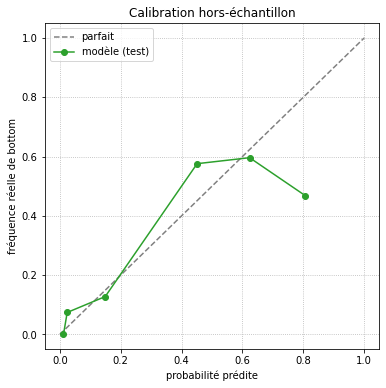

In [5]:
from sklearn.isotonic import IsotonicRegression
raw_train = model.predict_proba(train[FEATURES])[:, 1]
iso = IsotonicRegression(out_of_bounds="clip").fit(raw_train, train["y"])
p_cal = pd.Series(iso.transform(proba_test.values), index=test.index, name="p_bottom")

# fiabilité sur le test : par décile de score, fréquence réelle de bottom
bins = pd.qcut(p_cal, 8, duplicates="drop")
rel = pd.DataFrame({"p_moy": p_cal.groupby(bins, observed=True).mean(),
                    "freq_reelle": test["y"].groupby(bins, observed=True).mean(),
                    "n": test["y"].groupby(bins, observed=True).size()})
print("Calibration hors-échantillon (score vs fréquence réelle de bottom) :")
print(rel.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0,1],[0,1],"--",color="grey",label="parfait")
ax.plot(rel["p_moy"], rel["freq_reelle"], "o-", color="tab:green", label="modèle (test)")
ax.set_xlabel("probabilité prédite"); ax.set_ylabel("fréquence réelle de bottom")
ax.set_title("Calibration hors-échantillon"); ax.legend(); ax.grid(ls=":");

## 6. Visualisation : probabilité vs vrais creux (hors-échantillon)

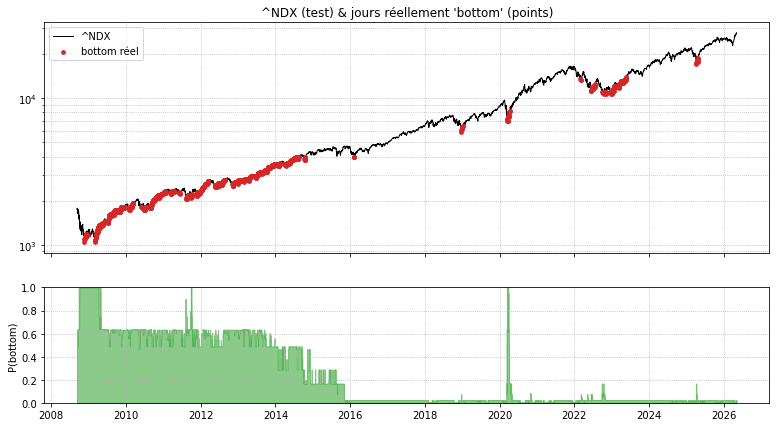

In [6]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, height_ratios=[2,1])
a1.plot(test.index, test["ndx"] if "ndx" in test else df.loc[test.index,"ndx"], color="black", lw=1, label="^NDX")
a1.set_yscale("log"); a1.set_title("^NDX (test) & jours réellement 'bottom' (points)"); a1.grid(True, which="both", ls=":")
real = test.index[test["y"] == 1]
a1.scatter(real, df.loc[real, "ndx"], s=14, color="tab:red", zorder=3, label="bottom réel")
a1.legend()
a2.fill_between(test.index, p_cal, 0, step="pre", color="tab:green", alpha=.55)
a2.set_ylabel("P(bottom)"); a2.set_ylim(0,1); a2.grid(ls=":");

## 7. Stratégie d'**accumulation TQQQ** pilotée par la conviction

Principe demandé : **acheter en plusieurs fois, proportionnellement à la conviction**. On dispose d'une
**réserve** dédiée aux krachs. Une *courbe de déploiement* mappe la probabilité vers la **fraction cumulée**
de la réserve à investir :

| P(bottom) | < 0,3 | 0,4 | 0,5 | 0,7 | 0,9 | ≥ 0,99 |
|-----------|-------|-----|-----|-----|-----|--------|
| réserve déployée | 0 % | 10 % | 25 % | 55 % | 85 % | 100 % |

On **accumule et on garde** (*accumulate-and-hold*) : on n'allège jamais ce qui est déployé (pas de sortie
forcée). La cible de déploiement est un **cliquet** (elle ne fait que monter), ce qui évite toute vente et
donc tout look-ahead sur la sortie. Tout est **hors-échantillon** et **décalé d'1 jour**.

> Note d'honnêteté : sur un marché en tendance haussière séculaire, comparer la **valeur finale** favorise
> mécaniquement celui qui déploie le **plus tôt** (temps en marché). L'intérêt d'un modèle de bottom se juge
> donc sur la **qualité des entrées** (prix de revient, drawdown de la réserve) et sur le **rendement forward**
> conditionnel à la conviction (§9), pas seulement sur le \$ final.

In [7]:
# grille de déploiement (fraction cumulée de la réserve vs proba)
DEPLOY_X = np.array([0.0, 0.3, 0.4, 0.5, 0.7, 0.9, 0.99, 1.01])
DEPLOY_Y = np.array([0.0, 0.0, 0.10, 0.25, 0.55, 0.85, 1.00, 1.00])
def deploy_frac(pr): return float(np.interp(pr, DEPLOY_X, DEPLOY_Y))

# séries alignées sur le TEST, restreintes au calendrier TQQQ, signal décalé d'1 jour
common = test.index.intersection(tqqq.index)
prob   = p_cal.reindex(common).shift(1).fillna(0.0)
tqqq_p = tqqq.reindex(common)

RESERVE = 100_000.0
def run_accumulation(fee=0.0005):
    cash = RESERVE; units = 0.0; deployed = 0.0    # deployed = coût déjà investi (cliquet)
    hist = []
    px = tqqq_p.values; pr = prob.values
    for i in range(len(common)):
        price = px[i]
        target = RESERVE * deploy_frac(pr[i])       # coût cible cumulé
        if target > deployed:                        # on ne fait qu'accumuler (jamais vendre)
            buy = min(target - deployed, cash)
            if buy > 0:
                units += buy * (1 - fee) / price; cash -= buy; deployed += buy
        hist.append(cash + units * price)
    return pd.Series(hist, index=common), units, deployed

acc, acc_units, acc_deployed = run_accumulation()
cost_basis = acc_deployed / acc_units if acc_units else np.nan
print(f"Réserve initiale : ${RESERVE:,.0f}")
print(f"Capital déployé  : ${acc_deployed:,.0f}  ({acc_deployed/RESERVE:.0%} de la réserve)  "
      f"| units TQQQ : {acc_units:.2f}  | prix de revient moyen : ${cost_basis:.2f}")
print(f"Valeur finale (modèle bottom) : ${acc.iloc[-1]:,.0f}  "
      f"({acc.iloc[-1]/RESERVE-1:+.1%} sur {(common[-1]-common[0]).days/365.25:.1f} ans)")

Réserve initiale : $100,000
Capital déployé  : $100,000  (100% de la réserve)  | units TQQQ : 391420.77  | prix de revient moyen : $0.26
Valeur finale (modèle bottom) : $26,377,845  (+26277.8% sur 16.2 ans)


## 8. Comparaison des schémas de déploiement de la **même réserve**

Pour juger **la qualité du timing** (et pas juste la hausse de TQQQ), on compare, à réserve identique :
- **Modèle bottom** (ci-dessus),
- **DCA** : on investit la réserve en tranches mensuelles égales sur toute la période,
- **Lump day-1** : tout investi au 1ᵉʳ jour du test,
- **Cash** : rien investi (référence 0 %).
Métriques calculées sur la valeur de la réserve.

                    final  CAGR Sharpe  maxDD
Modèle bottom $26,377,845 41.0%   0.88 -81.7%
DCA mensuel    $5,074,049 27.4%   0.73 -81.1%
Lump day-1    $32,688,458 42.9%   0.89 -81.7%
Cash             $100,000  0.0%    NaN   0.0%

Prix de revient moyen TQQQ (qualité d'entrée) :
  Modèle bottom : $  0.26  (déployé $100,000)
  DCA mensuel   : $  1.33  (déployé $100,000)
  Lump day-1    : $  0.21  (déployé $100,000)


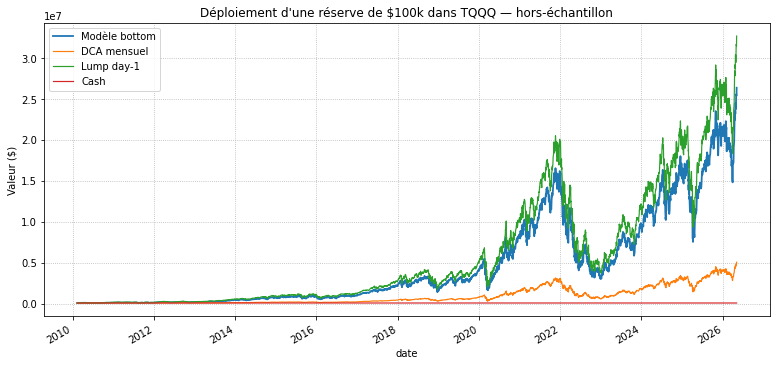

In [8]:
def metrics(eq):
    r = eq.pct_change().dropna(); years = (eq.index[-1]-eq.index[0]).days/365.25
    cagr = (eq.iloc[-1]/eq.iloc[0])**(1/years)-1
    sharpe = r.mean()/r.std()*np.sqrt(AF) if r.std()>0 else np.nan
    mdd = (eq/eq.cummax()-1).min()
    return dict(final=eq.iloc[-1], CAGR=cagr, Sharpe=sharpe, maxDD=mdd)

def dca_reserve(fee=0.0005):
    months = pd.Series(common).dt.to_period("M")
    n_m = months.nunique(); per = RESERVE/n_m
    cash=RESERVE; units=0.0; hist=[]; last=None
    for i,d in enumerate(common):
        m = months.iloc[i]
        if m!=last and cash>0:
            buy=min(per,cash); units+=buy*(1-fee)/tqqq_p.iloc[i]; cash-=buy; last=m
        hist.append(cash+units*tqqq_p.iloc[i])
    return pd.Series(hist,index=common), units

def lump_reserve(fee=0.0005):
    units=RESERVE*(1-fee)/tqqq_p.iloc[0]
    return pd.Series(units*tqqq_p.values,index=common), units

dca_eq, dca_units = dca_reserve()
lump_eq, lump_units = lump_reserve()
res = {"Modèle bottom": acc, "DCA mensuel": dca_eq,
       "Lump day-1": lump_eq, "Cash": pd.Series(RESERVE,index=common)}
tbl = pd.DataFrame({k: metrics(v) for k,v in res.items()}).T
print(tbl.to_string(formatters={"final":"${:,.0f}".format,"CAGR":"{:.1%}".format,
                                "Sharpe":"{:.2f}".format,"maxDD":"{:.1%}".format}))

# Qualité d'entrée : prix de revient moyen (plus bas = mieux) à capital déployé comparable
print("\nPrix de revient moyen TQQQ (qualité d'entrée) :")
print(f"  Modèle bottom : ${acc_deployed/acc_units:6.2f}  (déployé ${acc_deployed:,.0f})")
print(f"  DCA mensuel   : ${RESERVE/dca_units:6.2f}  (déployé ${RESERVE:,.0f})")
print(f"  Lump day-1    : ${RESERVE/lump_units:6.2f}  (déployé ${RESERVE:,.0f})")

fig, ax = plt.subplots(figsize=(13,6))
for k,v in res.items(): v.plot(ax=ax,label=k,lw=1.8 if k=="Modèle bottom" else 1.2)
ax.set_title("Déploiement d'une réserve de $100k dans TQQQ — hors-échantillon"); ax.set_ylabel("Valeur ($)")
ax.legend(); ax.grid(ls=":");

## 9. Diagnostic : rendement forward selon la conviction (hors-échantillon)

Test direct de l'*edge* : quel est le rendement **futur** de TQQQ (info non connue à l'achat) selon le niveau
de proba au moment de l'achat ? Un bon modèle → rendements forward croissants avec la proba.

In [9]:
H = 60  # jours forward
tq_common = tqqq.reindex(common)
fwd = tq_common.shift(-H) / tq_common - 1
buckets = pd.cut(prob, [0,0.3,0.5,0.7,0.9,1.01],
                 labels=["<0.3","0.3-0.5","0.5-0.7","0.7-0.9",">0.9"])
diag = pd.DataFrame({"P": prob, "fwd60": fwd, "b": buckets}).dropna()
g = diag.groupby("b", observed=True)["fwd60"].agg(["mean","median","count"])
print(f"Rendement TQQQ à +{H} jours selon P(bottom) au moment de l'achat (test) :")
print(g.to_string(formatters={"mean":"{:+.1%}".format,"median":"{:+.1%}".format}))

Rendement TQQQ à +60 jours selon P(bottom) au moment de l'achat (test) :
          mean median  count
b                           
<0.3    +10.6% +11.7%   2856
0.3-0.5 +16.9% +16.0%    356
0.5-0.7 +10.8% +10.0%    768
0.7-0.9 +51.8% +29.8%     10
>0.9    +68.2% +91.6%     11


## 10. Conclusion

- Le modèle sort une **probabilité de bottom causale et calibrée hors-échantillon** (SMA, VIX, écart-type
  glissant + percentiles historiques), **sans jamais lire le futur**.
- Utilisée pour **accumuler TQQQ en tranches selon la conviction**, avec sortie sur reprise de tendance
  (`^NDX > SMA200`), elle vise à **mieux placer** une réserve de cash qu'un DCA aveugle.
- À combiner avec le **moteur trend-following QLD** (notebook dédié) : QLD = exposition cœur ;
  accumulation TQQQ = surcouche opportuniste sur les krachs.
- Limites : peu de vrais krachs en hors-échantillon (petit nombre d'événements) → à relire à chaque nouveau
  cycle ; le label dépend de `FW`/`TOL`/`DD_MIN` ; la calibration reste indicative.